# Boat Image Classification using CNN

##Objective
This project aims to classify different types of boats using image data.

##Dataset
The dataset contains images of different boat categories, divided into training and testing sets.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import zipfile
import shutil
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Boat dataset(Assignment).zip"

'/content/drive/MyDrive/Boat dataset(Assignment).zip'


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Boat dataset(Assignment).zip'
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete!")

✅ Extraction complete!


## Data Loading and Preparation

The dataset was loaded from Google Drive and extracted into the working directory.

The training dataset originally contained images and a ground truth file. The images were reorganized into class-specific folders using the labels provided in the ground truth file.

This restructuring was necessary to make the dataset compatible with Keras' `flow_from_directory()` function.

In [ ]:
!ls /content/data
!ls "/content/data/boat data"

'boat data'
test  train


In [ ]:
train_path = "/content/data/boat data/train"
test_path = "/content/data/boat data/test"

In [ ]:
gt_file = os.path.join(train_path, "ground_truth.txt")

if os.path.exists(gt_file):
    with open(gt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        img_name, label = line.strip().split(";")
        label = label.strip()

        img_path = os.path.join(train_path, img_name)
        class_folder = os.path.join(train_path, label)

        os.makedirs(class_folder, exist_ok=True)

        if os.path.exists(img_path):
            shutil.move(img_path, os.path.join(class_folder, img_name))

    print("✅ Training data organized")
else:
    print("⚠️ Already organized or file missing")

✅ Training data organized


In [ ]:
train_classes = set(os.listdir(train_path))
print("Train classes:", train_classes)

Train classes: {'Mototopo', 'Motoscafo ACTV', 'Barchino', 'Alilaguna', 'Lancia: fino 10 m Marrone', 'Motopontone rettangolare', 'Ambulanza', 'Snapshot Barca Multipla', 'Lancia: fino 10 m Bianca', 'Patanella', 'Lancia: maggiore di 10 m Bianca', 'Sandolo a remi', 'ground_truth.txt', 'Snapshot Acqua', 'Thumbs.db', 'Lancia: fino 10 m', 'Raccolta rifiuti', 'Topa', 'Snapshot Barca Parziale', 'Vaporetto ACTV', 'Motobarca', 'Mototopo corto', 'Polizia', 'Gondola'}


In [ ]:
import os
import shutil

test_path = "/content/data/boat data/test"

for item in os.listdir(test_path):
    item_path = os.path.join(test_path, item)

    # Skip non-folders
    if not os.path.isdir(item_path):
        print(f"Skipping file: {item}")
        continue

    # Remove if not in training classes
    if item not in train_classes:
        print(f"Removing extra class: {item}")
        shutil.rmtree(item_path)

print("✅ Test folder cleaned")

Removing extra class: Lanciamaggioredi10mBianca
Removing extra class: Raccoltarifiuti
Removing extra class: Sanpierota
Removing extra class: Lanciafino10mMarrone
Removing extra class: Water
Removing extra class: Cacciapesca
Removing extra class: Lanciafino10mBianca
Removing extra class: Sandoloaremi
Removing extra class: Motopontonerettangolare
Removing extra class: Caorlina
Removing extra class: MotoscafoACTV
Skipping file: DBinfo.txt
Removing extra class: Lanciafino10m
Removing extra class: VaporettoACTV
Removing extra class: Lanciamaggioredi10mMarrone
Removing extra class: VigilidelFuoco
✅ Test folder cleaned


## Data Preprocessing

Image preprocessing was performed using ImageDataGenerator.

The following steps were applied:
- Rescaling pixel values (normalization)
- Data augmentation (rotation, shifting, flipping) for training data
- Splitting the dataset into training and validation sets using validation_split

This ensures the model generalizes better to unseen data.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 20% for validation
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 1584 images belonging to 22 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 385 images belonging to 22 classes.


In [ ]:
print(train_generator.num_classes)
print(validation_generator.num_classes)

22
22


## Model Building

A Convolutional Neural Network (CNN) was built using TensorFlow/Keras.

The model consists of:
- Convolutional layers for feature extraction
- MaxPooling layers for dimensionality reduction
- Fully connected (Dense) layers for classification
- Dropout layer to reduce overfitting

The final layer uses Softmax activation to classify images into multiple categories.

In [ ]:
from tensorflow.keras import layers, models

num_classes = train_generator.num_classes

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,478 (12.62 MB)

 Trainable params: 3,307,478 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model was trained using the training dataset and evaluated using the validation dataset.

Categorical cross-entropy was used as the loss function, and accuracy was used as the performance metric.

The model was trained for 10 epochs.

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4135 - loss: 2.1085 - val_accuracy: 0.5013 - val_loss: 1.6476
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6061 - loss: 1.5026 - val_accuracy: 0.6390 - val_loss: 1.3553
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6301 - loss: 1.3027 - val_accuracy: 0.6416 - val_loss: 1.2804
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6774 - loss: 1.1440 - val_accuracy: 0.6234 - val_loss: 1.2886
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7146 - loss: 0.9679 - val_accuracy: 0.6468 - val_loss: 1.2256
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7519 - loss: 0.8109 - val_accuracy: 0.6390 - val_loss: 1.3327
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8100 - loss: 0.6283 - val_accuracy: 0.6701 - val_loss: 1.3839
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8352 - loss: 0.4947 - val_accuracy: 0.6857 - val_loss:

## Model Training

The model was trained using the training dataset and evaluated using the validation dataset.

Categorical cross-entropy was used as the loss function, and accuracy was used as the performance metric.

The model was trained for 10 epochs.

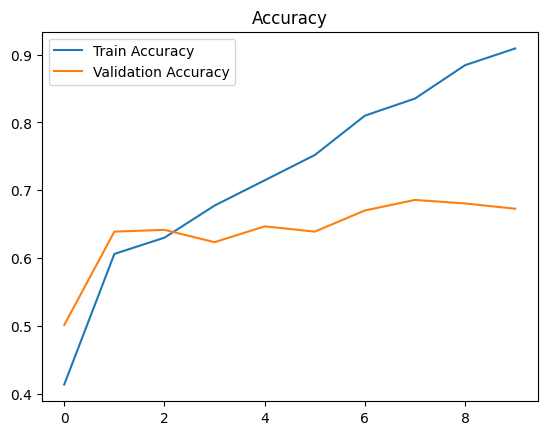

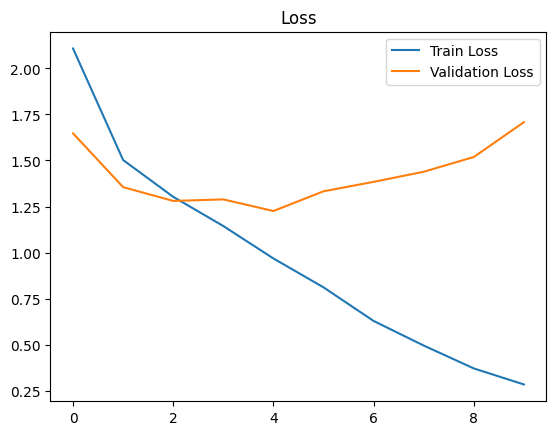

In [18]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

## Results and Evaluation

The model showed steady improvement in training accuracy across epochs.

However, after a certain point, validation accuracy stopped improving while training accuracy continued to increase. This indicates overfitting.

The best validation accuracy achieved was approximately 68%.

In [19]:
model.save("boat_classifier_model.h5")

## Conclusion

In this project, a Convolutional Neural Network (CNN) was successfully developed to classify different types of boats from images.

The dataset required significant preprocessing, including restructuring and cleaning, before it could be used effectively. This highlights the importance of proper data preparation in machine learning projects.

The model achieved a validation accuracy of approximately 68%, which is a reasonable result given the complexity and limitations of the dataset.

Some level of overfitting was observed, as the model performed better on training data than on validation data. This suggests that further improvements could be made by increasing the dataset size, applying more regularization techniques, or using more advanced architectures.

Overall, this project provided practical experience in handling real-world data challenges, building deep learning models, and evaluating their performance.